## Predictions : Tree based models

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### importing the system path
import sys
sys.path.append('../')

In [ ]:
### importing the functions from the src
from src.data.load_data import load_data, get_info, get_nan_duplicates_shape, get_shape, drop_col
from src.processing.split_data import split_data_local
from src.predictions.predictions_plot import verify_split, model_predict_test, best_model_predict_valid, other_model_predict_valid

In [4]:
### importing the models to be used for the predictions
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

##### =========== Train data first ====================

In [5]:
### setting up the data path
train_tree_path = '../data/model_ready/train_tree.csv'

In [6]:
### loading the data
train_tree = load_data(train_tree_path)
train_tree.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,0,0,0,0,1,0,0,0,0,0,...,112.75,4,142,3674.33,0.3668,0,1,4,13,16
1,1,0,0,1,0,0,1,0,0,1,...,199.95,1,32,796.99,0.4866,0,0,3,27,5
2,0,0,0,0,1,0,0,1,0,1,...,234.75,2,203,2286.33,0.2961,1,0,9,27,23
3,0,1,0,1,0,0,0,0,0,0,...,344.98,2,137,4924.98,0.3362,0,0,9,10,13
4,0,1,0,1,0,0,0,1,0,0,...,456.77,1,8,4924.36,0.0804,0,0,1,13,6


In [7]:
### checking the shape of the data
get_shape(train_tree)

(40000, 34)


In [8]:
### dropping the 'Failed_Transaction_Count_7d' column, 
### because the column is not causing the leakage, but will make the 'split' for the trees more biased
### that has been the case in the 'v1' version of this project

In [9]:
### dropping the 'Failed_Transaction_Count_7d' column from the dataset
drop_col(train_tree, 'Failed_Transaction_Count_7d')
train_tree.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,0,0,0,0,1,0,0,0,0,0,...,5,112.75,142,3674.33,0.3668,0,1,4,13,16
1,1,0,0,1,0,0,1,0,0,1,...,8,199.95,32,796.99,0.4866,0,0,3,27,5
2,0,0,0,0,1,0,0,1,0,1,...,7,234.75,203,2286.33,0.2961,1,0,9,27,23
3,0,1,0,1,0,0,0,0,0,0,...,8,344.98,137,4924.98,0.3362,0,0,9,10,13
4,0,1,0,1,0,0,0,1,0,0,...,6,456.77,8,4924.36,0.0804,0,0,1,13,6


In [10]:
### checking the shape again
get_shape(train_tree)

(40000, 33)

In [11]:
### splitting the data into the train/test data
X_train, X_test, y_train, y_test = split_data_local(train_tree, target_feature = 'Fraud_Label')

In [12]:
### veryfying the split
verify_split(X_train, X_test, y_train, y_test)

X_train : (30000, 32) :: X_test : (10000, 32) :: y_train : (30000,) :: y_test : (10000,)


In [13]:
### X_train.head
X_train.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
26898,0,0,1,1,0,0,0,0,1,0,...,0,9,47.66,57,2105.43,0.2490,0,2,17,16
27635,1,0,0,0,1,1,0,0,0,0,...,0,8,356.63,216,3902.39,0.8446,0,12,24,5
3036,0,1,0,1,0,0,1,0,0,0,...,0,11,202.53,173,4060.98,0.9462,0,7,27,2
5604,0,0,0,0,1,0,1,0,0,0,...,1,12,495.32,113,642.74,0.9844,0,8,22,10
36111,0,0,0,0,1,1,0,0,0,0,...,0,12,266.01,152,3267.55,0.6151,0,10,14,12


In [14]:
### y_test.head()
y_test.head()

32823    0
16298    0
28505    1
6689     0
26893    0
Name: Fraud_Label, dtype: int64

##### predictions

In [15]:
### 1. Decision tree classifier
dtc = DecisionTreeClassifier()
dtc_path = '../models/tree/dtc.pkl'

Accuracy score : 0.7183
Confusion matrix : 
[[5291 1527]
 [1290 1892]]
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      6818
           1       0.55      0.59      0.57      3182

    accuracy                           0.72     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.72      0.72      0.72     10000



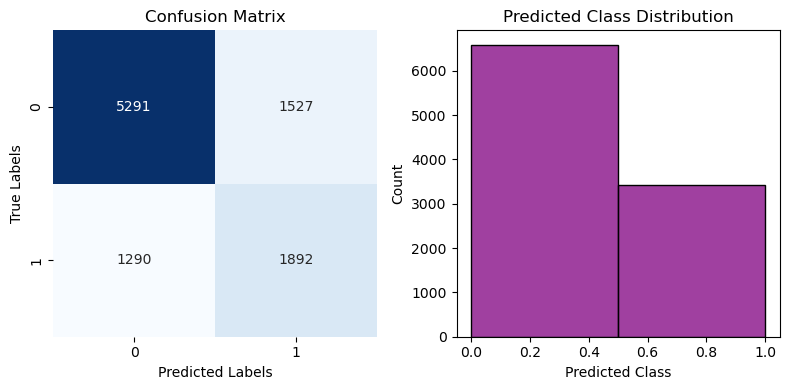

In [16]:
### predictions and metrices
model_predict_test(X_train, X_test, y_train, y_test, model = dtc, model_path = dtc_path)

Accuracy score : 0.8343
Confusion matrix : 
[[6818    0]
 [1657 1525]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6818
           1       1.00      0.48      0.65      3182

    accuracy                           0.83     10000
   macro avg       0.90      0.74      0.77     10000
weighted avg       0.87      0.83      0.81     10000



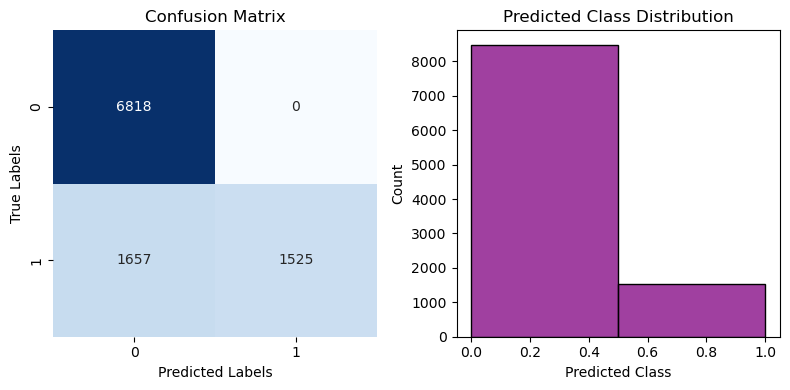

In [23]:
### 2. Random forest classifier
rfc = RandomForestClassifier()
rfc_path = '../models/tree/rfc.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = rfc, model_path = rfc_path)

c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy score : 0.8342
Confusion matrix : 
[[6817    1]
 [1657 1525]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6818
           1       1.00      0.48      0.65      3182

    accuracy                           0.83     10000
   macro avg       0.90      0.74      0.77     10000
weighted avg       0.87      0.83      0.81     10000



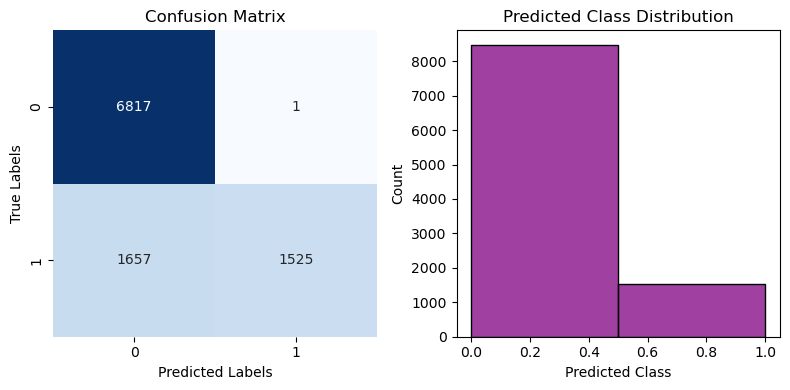

In [24]:
### 3. Adaboost classifier
abc = AdaBoostClassifier()
abc_path = '../models/tree/abc.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = abc, model_path = abc_path)

Accuracy score : 0.8341
Confusion matrix : 
[[6815    3]
 [1656 1526]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6818
           1       1.00      0.48      0.65      3182

    accuracy                           0.83     10000
   macro avg       0.90      0.74      0.77     10000
weighted avg       0.87      0.83      0.81     10000



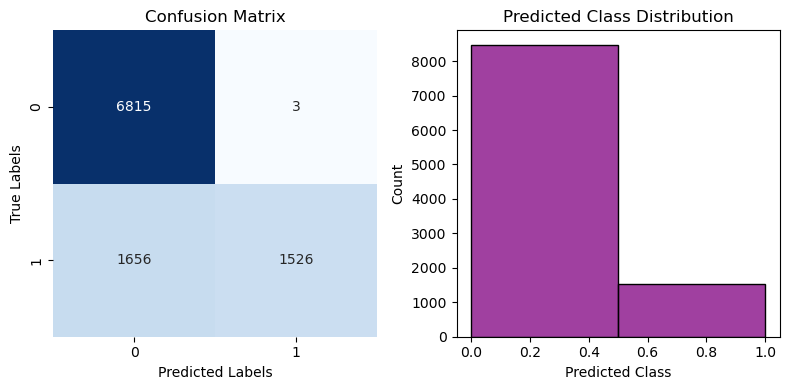

In [26]:
### 4. Gradient boost classifier
gbc = GradientBoostingClassifier()
gbc_path = '../models/tree/gbc.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = gbc, model_path = gbc_path)

Accuracy score : 0.6815
Confusion matrix : 
[[6813    5]
 [3180    2]]
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      6818
           1       0.29      0.00      0.00      3182

    accuracy                           0.68     10000
   macro avg       0.48      0.50      0.41     10000
weighted avg       0.56      0.68      0.55     10000



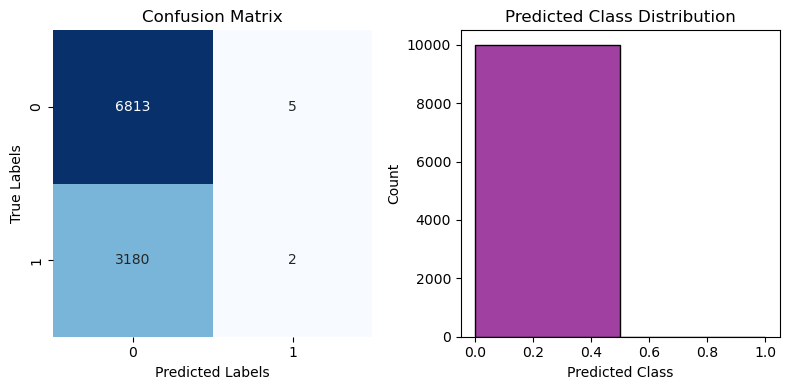

In [27]:
### 5. GausianNB
gnb = GaussianNB()
gnb_path = '../models/probablity/gnb.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = gnb, model_path = gnb_path)

##### =============== Valid Data ===================

In [28]:
### setting up the data path
valid_tree_path = '../data/model_ready/valid_tree.csv'

In [29]:
### loading the data
valid_tree = load_data(valid_tree_path)
valid_tree.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
0,0,1,0,1,0,0,0,1,0,0,...,2,350.41,3,214,4568.48,0.6865,1,2,10,2
1,1,0,0,1,0,0,1,0,0,0,...,11,47.14,1,78,297.39,0.5322,1,3,26,22
2,0,0,0,0,0,0,0,0,1,0,...,7,160.14,2,59,4792.40,0.4924,0,8,5,12
3,0,0,1,0,1,1,0,0,0,0,...,3,340.38,4,143,3318.08,0.5503,0,1,22,19
4,1,0,0,0,1,0,0,1,0,0,...,1,149.80,0,227,573.20,0.2208,0,8,20,12


In [30]:
### checking the shape
get_shape(valid_tree)

(10000, 33)

In [33]:
### dropping off the 'Failed_Transaction_Count_7d' column, as it was dropped from the dataset earlier
### so the models were trained without it and the 
### inference models will not work if we don't drop the columns

In [34]:
### dropping the column 'Failed_Transaction_Count_7d' column
drop_col(valid_tree, 'Failed_Transaction_Count_7d')
valid_tree.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
0,0,1,0,1,0,0,0,1,0,0,...,0,2,350.41,214,4568.48,0.6865,1,2,10,2
1,1,0,0,1,0,0,1,0,0,0,...,1,11,47.14,78,297.39,0.5322,1,3,26,22
2,0,0,0,0,0,0,0,0,1,0,...,0,7,160.14,59,4792.40,0.4924,0,8,5,12
3,0,0,1,0,1,1,0,0,0,0,...,0,3,340.38,143,3318.08,0.5503,0,1,22,19
4,1,0,0,0,1,0,0,1,0,0,...,0,1,149.80,227,573.20,0.2208,0,8,20,12


In [35]:
### checking the shape again
get_shape(valid_tree)

(10000, 32)

##### best model : Random forest (predictions on valid)

In [ ]:
### 'Random forest' predictions on 'valid_tree'
rfc_inference_path = '../models/tree/rfc.pkl'
y_pred_best = best_model_predict_valid(valid_tree, rfc_inference_path)

In [38]:
### checking the 'y_pred_best'
y_pred_best

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

##### other model predictions (on valid data)

Accuracy score : 0.8115
Confusion matrix : 
[[6591 1885]
 [   0 1524]]
              precision    recall  f1-score   support

           0       1.00      0.78      0.87      8476
           1       0.45      1.00      0.62      1524

    accuracy                           0.81     10000
   macro avg       0.72      0.89      0.75     10000
weighted avg       0.92      0.81      0.84     10000



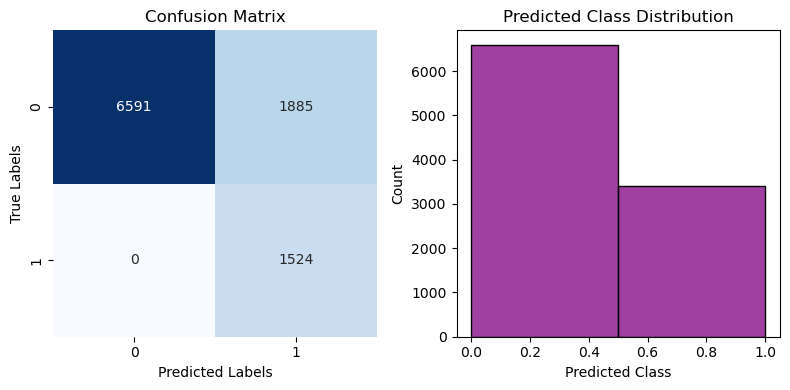

In [41]:
### 1. Decision Tree
dtc_inference_path = '../models/tree/dtc.pkl'
other_model_predict_valid(valid_tree, y_pred_best, other_model_path = dtc_inference_path)

Accuracy score : 0.9997
Confusion matrix : 
[[8473    3]
 [   0 1524]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8476
           1       1.00      1.00      1.00      1524

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



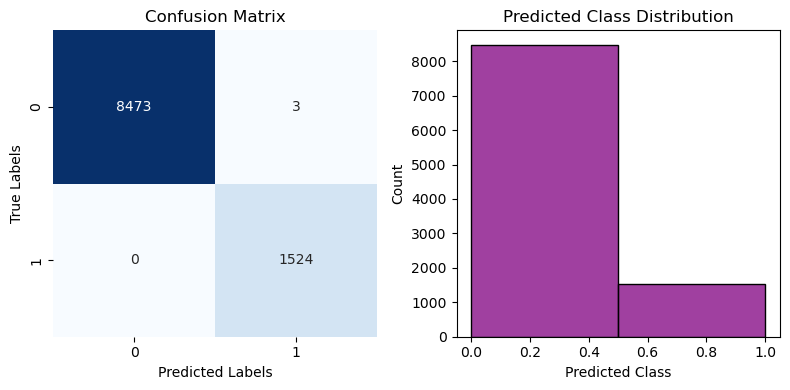

In [42]:
### 2. Adaboost
abc_inference_path = '../models/tree/abc.pkl'
other_model_predict_valid(valid_tree, y_pred_best, other_model_path = abc_inference_path)

Accuracy score : 0.9996
Confusion matrix : 
[[8472    4]
 [   0 1524]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8476
           1       1.00      1.00      1.00      1524

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



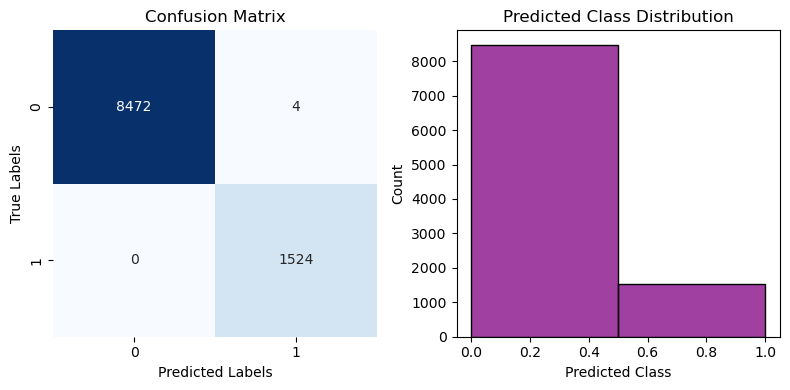

In [43]:
### 3. Gradient boost
gbc_inference_path = '../models/tree/gbc.pkl'
other_model_predict_valid(valid_tree, y_pred_best, other_model_path = gbc_inference_path)

Accuracy score : 0.847
Confusion matrix : 
[[8469    7]
 [1523    1]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8476
           1       0.12      0.00      0.00      1524

    accuracy                           0.85     10000
   macro avg       0.49      0.50      0.46     10000
weighted avg       0.74      0.85      0.78     10000



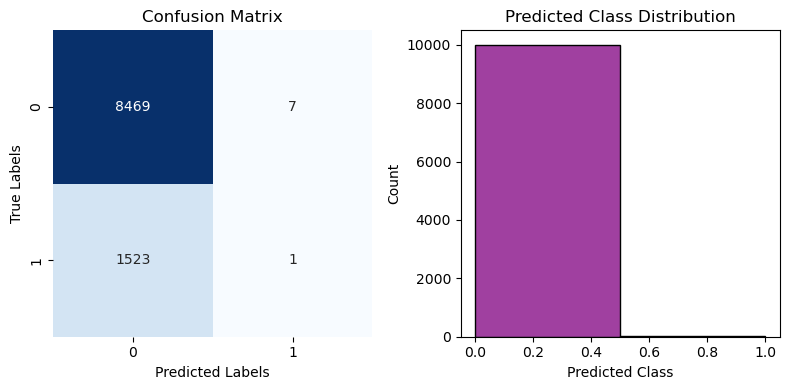

In [44]:
### 4. Gausian NB
gnb_inference_path = '../models/probablity/gnb.pkl'
other_model_predict_valid(valid_tree, y_pred_best, other_model_path = gnb_inference_path)